In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [11]:
df = pd.read_csv("../data/round_1/prices_round_1_day_0.csv", delimiter= ";")
df.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10013.0,30.0,NaN,NaN,NaN,NaN,10013.0,0.0
1,0,0,INTARIAN_PEPPER_ROOT,11991.0,19.0,NaN,NaN,NaN,NaN,12006.0,10.0,12009.0,19.0,NaN,NaN,11998.5,0.0
2,0,100,INTARIAN_PEPPER_ROOT,11994.0,9.0,11991.0,23.0,NaN,NaN,12007.0,9.0,12010.0,23.0,NaN,NaN,12000.5,0.0
3,0,100,ASH_COATED_OSMIUM,9995.0,13.0,NaN,NaN,NaN,NaN,10011.0,13.0,10013.0,30.0,NaN,NaN,10003.0,0.0
4,0,200,INTARIAN_PEPPER_ROOT,11991.0,20.0,NaN,NaN,NaN,NaN,12007.0,11.0,12010.0,20.0,NaN,NaN,11999.0,0.0



ADF Test Results for ASH_COATED_OSMIUM
Test Statistic:  -100.095263
P-value:         0.000000
Lags Used:       0
Observations:    9999

Critical Values:
  1%: -3.4310
  5%: -2.8618
  10%: -2.5669

Interpretation:
✓ MEAN REVERTING (p=0.000000 < 0.05)
  → Series is stationary, reject unit root hypothesis
  → Good for market making strategies

ADF Test Results for INTARIAN_PEPPER_ROOT
Test Statistic:  -4.752893
P-value:         0.000067
Lags Used:       38
Observations:    9961

Critical Values:
  1%: -3.4310
  5%: -2.8618
  10%: -2.5669

Interpretation:
✓ MEAN REVERTING (p=0.000067 < 0.05)
  → Series is stationary, reject unit root hypothesis
  → Good for market making strategies


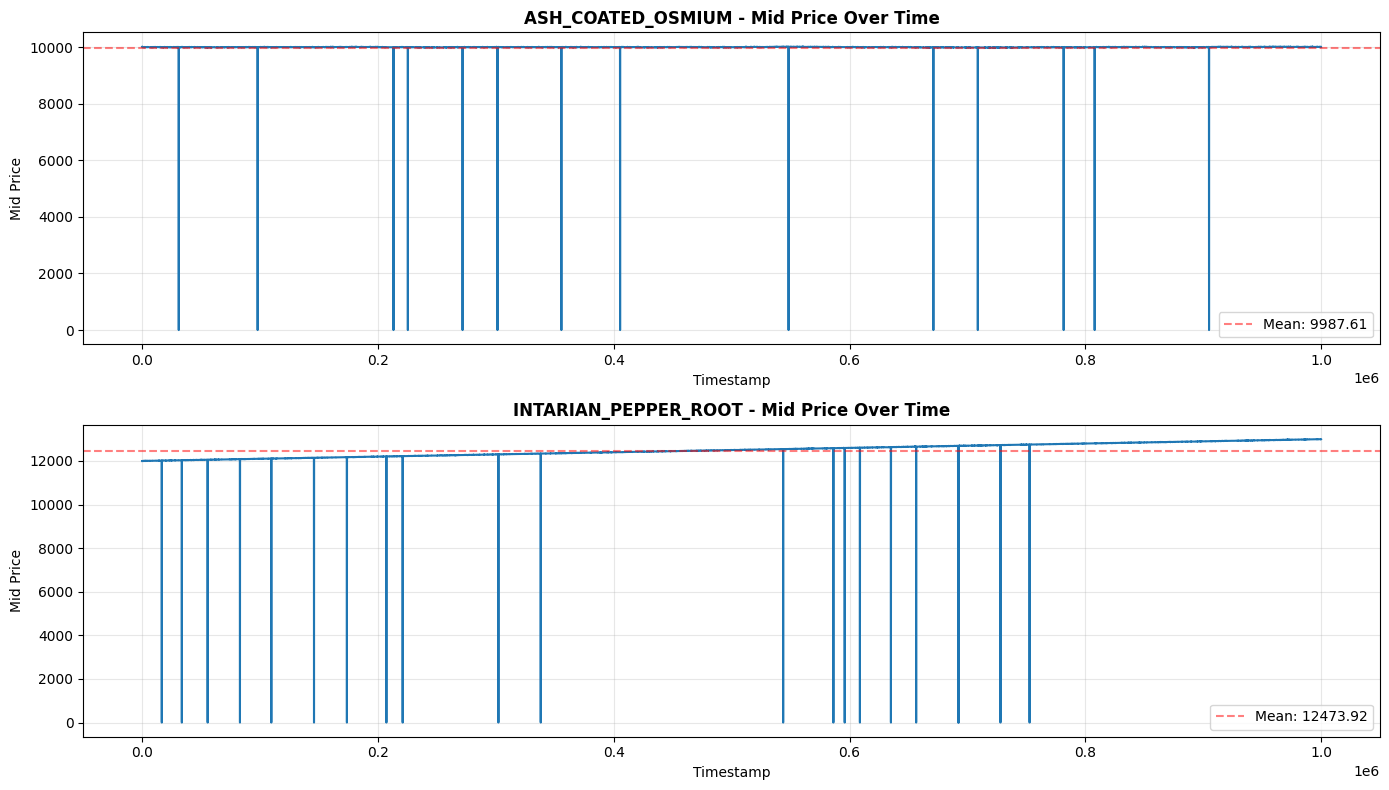


Summary: Mean Reversion Test Results
ASH_COATED_OSMIUM              | p-value: 0.000000 | ✓ MEAN REVERTING
INTARIAN_PEPPER_ROOT           | p-value: 0.000067 | ✓ MEAN REVERTING


In [12]:
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# ADF Test for mean reversion
def test_mean_reversion(price_series, name=""):
    """
    Run Augmented Dickey-Fuller test to check for mean reversion.
    
    Null hypothesis (H0): Series has a unit root (non-stationary, NOT mean reverting)
    Alternative (H1): Series is stationary (mean reverting)
    
    If p-value < 0.05, reject H0 → Series is mean reverting
    If p-value >= 0.05, fail to reject H0 → Series is NOT mean reverting
    """
    result = adfuller(price_series.dropna(), autolag='AIC')
    
    print(f"\n{'='*60}")
    print(f"ADF Test Results for {name}")
    print(f"{'='*60}")
    print(f"Test Statistic:  {result[0]:.6f}")
    print(f"P-value:         {result[1]:.6f}")
    print(f"Lags Used:       {result[2]}")
    print(f"Observations:    {result[3]}")
    print(f"\nCritical Values:")
    for key, value in result[4].items():
        print(f"  {key}: {value:.4f}")
    
    print(f"\n{'Interpretation:'}")
    if result[1] < 0.05:
        print(f"✓ MEAN REVERTING (p={result[1]:.6f} < 0.05)")
        print(f"  → Series is stationary, reject unit root hypothesis")
        print(f"  → Good for market making strategies")
    else:
        print(f"✗ NOT MEAN REVERTING (p={result[1]:.6f} >= 0.05)")
        print(f"  → Series has unit root, non-stationary")
        print(f"  → Better for trend-following strategies")
    
    return result

# Test each product separately
products = df['product'].unique()
adf_results = {}

for product in products:
    product_data = df[df['product'] == product]['mid_price']
    adf_results[product] = test_mean_reversion(product_data, name=product)

# Visualize prices for each product
fig, axes = plt.subplots(len(products), 1, figsize=(14, 4*len(products)))
if len(products) == 1:
    axes = [axes]

for idx, product in enumerate(products):
    product_data = df[df['product'] == product]
    axes[idx].plot(product_data['timestamp'], product_data['mid_price'], linewidth=1.5)
    axes[idx].set_title(f'{product} - Mid Price Over Time', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Timestamp')
    axes[idx].set_ylabel('Mid Price')
    axes[idx].grid(True, alpha=0.3)
    
    # Add mean line
    mean_price = product_data['mid_price'].mean()
    axes[idx].axhline(y=mean_price, color='r', linestyle='--', alpha=0.5, label=f'Mean: {mean_price:.2f}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'='*60}")
print(f"Summary: Mean Reversion Test Results")
print(f"{'='*60}")
for product, result in adf_results.items():
    status = "✓ MEAN REVERTING" if result[1] < 0.05 else "✗ TRENDING"
    print(f"{product:30} | p-value: {result[1]:.6f} | {status}")


## sizing

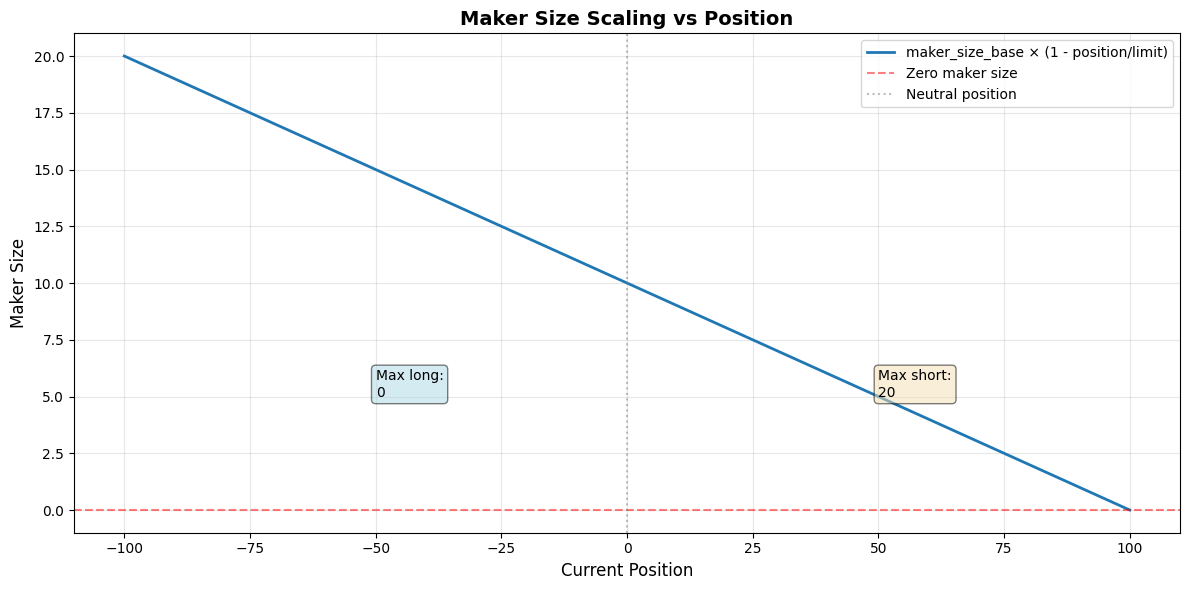

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def plot_maker_size_scaling(maker_size_base: int = 20, position_limit: int = 80):
    """
    Plot how maker_size scales with position.
    
    Args:
        maker_size_base: The base maker size (default from params)
        position_limit: Your position limit (e.g., 100)
    """
    # Generate position range from -limit to +limit
    positions = np.linspace(-position_limit, position_limit, 40)
    
    # Calculate maker_size for each position: maker_size_base * (1 - position/limit)
    maker_sizes = maker_size_base * (1 - positions / position_limit)
    
    # Create the plot
    plt.figure(figsize=(12, 6))
    plt.plot(positions, maker_sizes, linewidth=2, label='maker_size_base × (1 - position/limit)')
    
    # Add reference lines
    plt.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Zero maker size')
    plt.axvline(x=0, color='gray', linestyle=':', alpha=0.5, label='Neutral position')
    
    # Labels and formatting
    plt.xlabel('Current Position', fontsize=12)
    plt.ylabel('Maker Size', fontsize=12)
    plt.title('Maker Size Scaling vs Position', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    
    # Add annotations
    plt.text(position_limit * 0.5, maker_size_base * 0.5, 
             f'Max short:\n{maker_size_base * 2:.0f}', 
             fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.text(-position_limit * 0.5, maker_size_base * 0.5, 
             f'Max long:\n0', 
             fontsize=10, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

# Call it with your actual parameters
plot_maker_size_scaling(maker_size_base=10, position_limit=100)

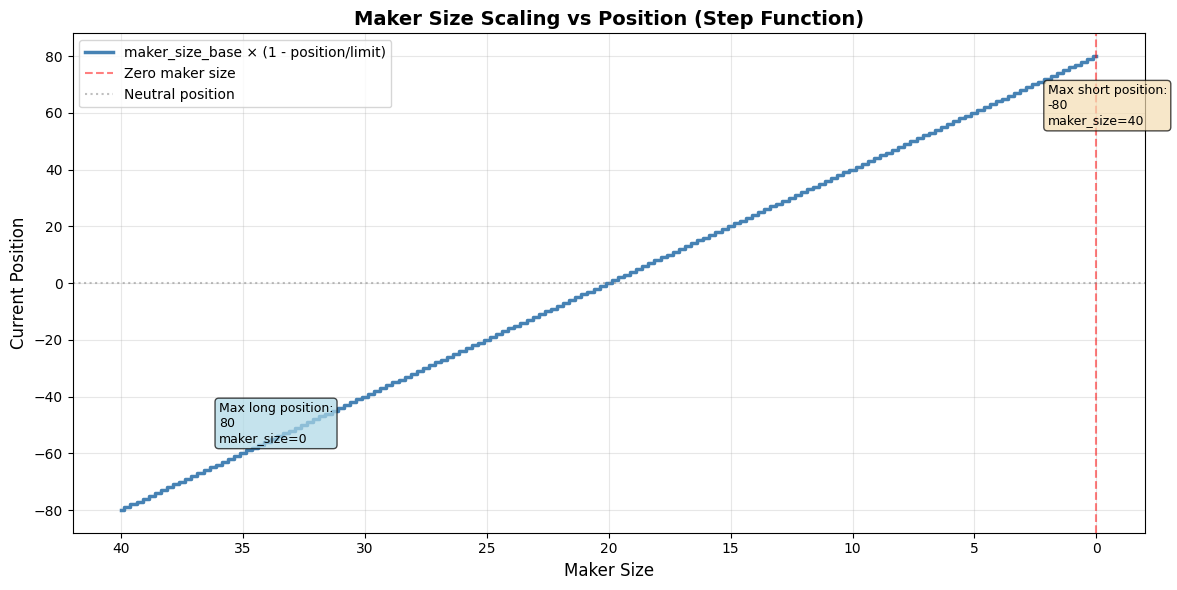

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def plot_maker_size_scaling(maker_size_base: int = 40, position_limit: int = 80):
    """
    Plot how maker_size scales with position (step function).
    
    Args:
        maker_size_base: The base maker size (default from params)
        position_limit: Your position limit (e.g., 80)
    """
    # Generate integer positions from -limit to +limit
    positions = np.arange(-position_limit, position_limit + 1, 1)
    
    # Calculate maker_size for each position: maker_size_base * (1 - position/limit)
    maker_sizes = maker_size_base * (1 - positions / position_limit)
    
    # Create the plot
    plt.figure(figsize=(12, 6))
    plt.step(maker_sizes, positions, where='mid', linewidth=2.5, 
             label='maker_size_base × (1 - position/limit)', color='steelblue')
    
    # Add reference lines
    plt.axvline(x=0, color='r', linestyle='--', alpha=0.5, label='Zero maker size')
    plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5, label='Neutral position')
    
    # Reverse x-axis (high to low)
    plt.gca().invert_xaxis()
    
    # Labels and formatting
    plt.xlabel('Maker Size', fontsize=12)
    plt.ylabel('Current Position', fontsize=12)
    plt.title('Maker Size Scaling vs Position (Step Function)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    
    # Add annotations for extremes
    plt.text(maker_size_base * 0.1, position_limit * 0.7, 
             f'Max short position:\n{-position_limit}\nmaker_size={maker_size_base * 2:.0f}', 
             fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    plt.text(maker_size_base * 1.8, -position_limit * 0.7, 
             f'Max long position:\n{position_limit}\nmaker_size=0', 
             fontsize=9, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    
    plt.tight_layout()
    plt.show()

# Call it with your actual parameters
plot_maker_size_scaling(maker_size_base=20, position_limit=80)

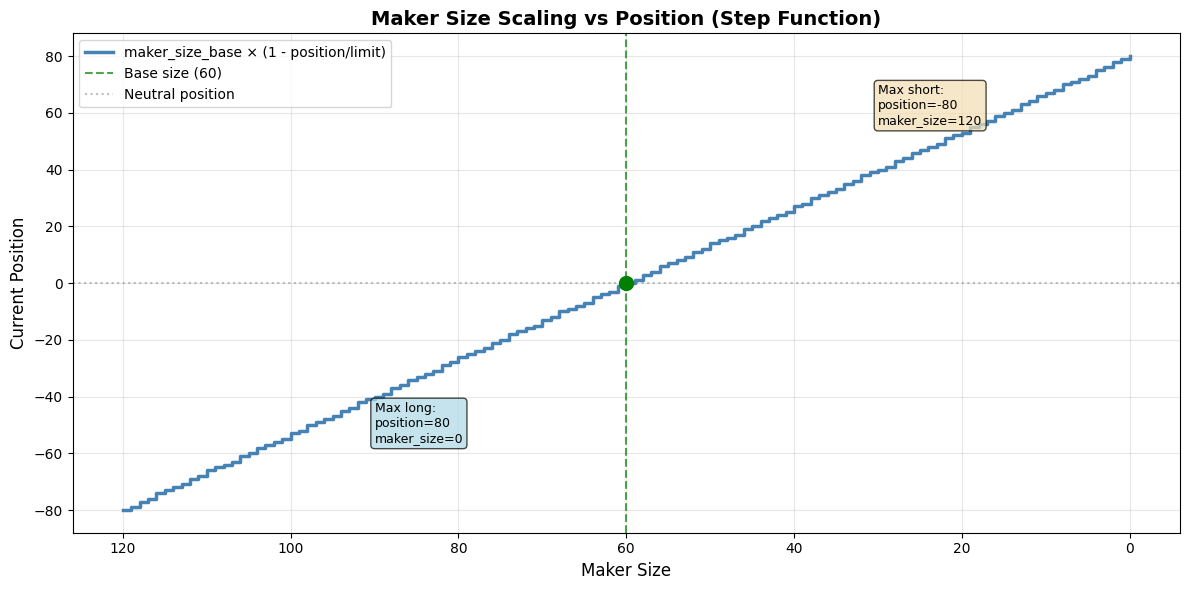

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_maker_size_scaling(maker_size_base: int = 40, position_limit: int = 80):
    """
    Plot how maker_size scales with position (step function with discrete jumps).
    Shows only steps at integer maker_size values.
    
    Args:
        maker_size_base: The base maker size (default from params)
        position_limit: Your position limit (e.g., 80)
    """
    # Generate integer positions from -limit to +limit
    positions = np.arange(-position_limit, position_limit + 1, 1)
    
    # Calculate maker_size for each position: maker_size_base * (1 - position/limit)
    maker_sizes = maker_size_base * (1 - positions / position_limit)
    
    # Round to integers to get discrete steps
    maker_sizes_int = np.round(maker_sizes).astype(int)
    
    # Create the plot
    plt.figure(figsize=(12, 6))
    plt.step(maker_sizes_int, positions, where='post', linewidth=2.5, 
             label='maker_size_base × (1 - position/limit)', color='steelblue')
    
    # Add reference lines
    plt.axvline(x=maker_size_base, color='g', linestyle='--', alpha=0.7, label=f'Base size ({maker_size_base})')
    plt.axhline(y=0, color='gray', linestyle=':', alpha=0.5, label='Neutral position')
    
    # Reverse x-axis (high to low)
    plt.gca().invert_xaxis()
    
    # Labels and formatting
    plt.xlabel('Maker Size', fontsize=12)
    plt.ylabel('Current Position', fontsize=12)
    plt.title('Maker Size Scaling vs Position (Step Function)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    
    # Add annotations for key points
    plt.plot(maker_size_base, 0, 'go', markersize=10)
    
    plt.text(maker_size_base * 0.5, position_limit * 0.7, 
             f'Max short:\nposition={-position_limit}\nmaker_size={maker_size_base * 2:.0f}', 
             fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    plt.text(maker_size_base * 1.5, -position_limit * 0.7, 
             f'Max long:\nposition={position_limit}\nmaker_size=0', 
             fontsize=9, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
    
    plt.tight_layout()
    plt.show()

# Call it with your actual parameters
plot_maker_size_scaling(maker_size_base=60, position_limit=80)

In [14]:
import plotly.graph_objects as go
import numpy as np

def plot_maker_size_scaling_plotly(maker_size_base: int = 40, maker_size_base2: int = None, position_limit: int = 80):
    """
    Plot how maker_size scales with position (step function with interactive hover).
    Compare two different maker_size_base values.
    
    Args:
        maker_size_base: The first base maker size (default from params)
        maker_size_base2: The second base maker size for comparison (optional)
        position_limit: Your position limit (e.g., 80)
    """
    # Generate integer positions from -limit to +limit
    positions = np.arange(-position_limit, position_limit + 1, 1)
    
    # Calculate maker_size for each position: maker_size_base * (1 - position/limit)
    maker_sizes = maker_size_base * (1 - positions / position_limit)
    maker_sizes_int = np.round(maker_sizes).astype(int)
    
    # Create the plot
    fig = go.Figure()
    
    # Add first curve
    fig.add_trace(go.Scatter(
        x=maker_sizes_int,
        y=positions,
        mode='lines',
        line=dict(color='steelblue', width=2.5),
        name=f'maker_size_base = {maker_size_base}',
        hovertemplate='<b>Position:</b> %{y}<br><b>Maker Size:</b> %{x}<extra></extra>'
    ))
    
    # Add second curve if provided
    if maker_size_base2 is not None:
        maker_sizes2 = maker_size_base2 * (1 - positions / position_limit)
        maker_sizes_int2 = np.round(maker_sizes2).astype(int)
        
        fig.add_trace(go.Scatter(
            x=maker_sizes_int2,
            y=positions,
            mode='lines',
            line=dict(color='coral', width=2.5),
            name=f'maker_size_base = {maker_size_base2}',
            hovertemplate='<b>Position:</b> %{y}<br><b>Maker Size:</b> %{x}<extra></extra>'
        ))
    
    # Add base size reference lines
    fig.add_vline(
        x=maker_size_base,
        line_dash="dash",
        line_color="steelblue",
        annotation_text=f"Base size 1 ({maker_size_base})",
        annotation_position="top"
    )
    
    if maker_size_base2 is not None:
        fig.add_vline(
            x=maker_size_base2,
            line_dash="dash",
            line_color="coral",
            annotation_text=f"Base size 2 ({maker_size_base2})",
            annotation_position="top"
        )
    
    # Add neutral position reference line
    fig.add_hline(
        y=0,
        line_dash="dot",
        line_color="gray",
        annotation_text="Neutral position",
        annotation_position="right"
    )
    
    # Add base point markers
    fig.add_trace(go.Scatter(
        x=[maker_size_base],
        y=[0],
        mode='markers',
        marker=dict(color='steelblue', size=10),
        name=f'Base point 1 (pos=0)',
        hovertemplate='<b>Position:</b> 0<br><b>Maker Size:</b> ' + str(maker_size_base) + '<extra></extra>'
    ))
    
    if maker_size_base2 is not None:
        fig.add_trace(go.Scatter(
            x=[maker_size_base2],
            y=[0],
            mode='markers',
            marker=dict(color='coral', size=10),
            name=f'Base point 2 (pos=0)',
            hovertemplate='<b>Position:</b> 0<br><b>Maker Size:</b> ' + str(maker_size_base2) + '<extra></extra>'
        ))
    
    # Update layout
    fig.update_layout(
        title='Maker Size Scaling vs Position (Step Function)',
        xaxis_title='Maker Size',
        yaxis_title='Current Position',
        hovermode='closest',
        template='plotly_white',
        width=1200,
        height=600,
        xaxis=dict(autorange='reversed'),
        showlegend=True,
    )
    
    fig.show()

# Call it with your actual parameters
plot_maker_size_scaling_plotly(maker_size_base=40, maker_size_base2=60, position_limit=80)